# WorldSim v2 Baseline Training


## 1. Repo Root & Environment


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd()
repo_marker = cwd / 'training/run_qlora_train.py'
notebook_marker = cwd / 'notebooks/dgx_spark_v2_baseline_train.ipynb'
assert repo_marker.exists() and notebook_marker.exists(), (
    f'Run this notebook from the WorldSim repo root. cwd={cwd} repo_marker={repo_marker}'
)
{
    'python_executable': sys.executable,
    'cwd': str(cwd),
    'repo_marker': str(repo_marker),
    'repo_marker_exists': repo_marker.exists(),
}


{'python_executable': '/home/hyunlord/github/diffusion-study/.venv/bin/python3',
 'cwd': '/home/hyunlord/github/worldsim-training',
 'repo_marker': '/home/hyunlord/github/worldsim-training/training/run_qlora_train.py',
 'repo_marker_exists': True}

## 2. Environment Visibility


In [2]:
from training.lib.qlora_smoke import get_environment_summary

environment = get_environment_summary()
torch_info = environment.get('torch', {})
training_stack = {
    name: environment.get(name, {'available': False, 'version': None})
    for name in ('transformers', 'peft', 'trl', 'datasets', 'accelerate', 'bitsandbytes')
}
try:
    import outlines
    outlines_status = {'available': True, 'version': getattr(outlines, '__version__', None)}
except ImportError:
    outlines_status = {'available': False, 'version': None}
env_visibility = {
    'python_executable': environment.get('python', {}).get('executable'),
    'cwd': environment.get('cwd'),
    'torch_version': torch_info.get('version'),
    'torch_cuda_version': torch_info.get('cuda_version'),
    'torch_cuda_available': torch_info.get('cuda_available'),
    'gpu_count': torch_info.get('cuda_device_count', 0),
    'gpu_names': torch_info.get('cuda_device_names', []),
    'training_stack': training_stack,
    'outlines': outlines_status,
    'environment': environment,
}
env_visibility


/home/hyunlord/github/diffusion-study/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'python_executable': '/home/hyunlord/github/diffusion-study/.venv/bin/python3',
 'cwd': '/home/hyunlord/github/worldsim-training',
 'torch_version': '2.12.0.dev20260225+cu130',
 'torch_cuda_version': '13.0',
 'torch_cuda_available': True,
 'gpu_count': 1,
 'gpu_names': ['NVIDIA GB10'],
 'training_stack': {'transformers': {'available': True, 'version': '5.2.0'},
  'peft': {'available': True, 'version': '0.18.1'},
  'trl': {'available': False,
   'error': "ModuleNotFoundError: No module named 'trl'"},
  'datasets': {'available': True, 'version': '4.7.0'},
  'accelerate': {'available': True, 'version': '1.12.0'},
  'bitsandbytes': {'available': True, 'version': '0.49.2'}},
 'outlines': {'available': True, 'version': None},
 'environment': {'python': {'version': '3.12.3',
   'executable': '/home/hyunlord/github/diffusion-study/.venv/bin/python3'},
  'platform': {'system': 'Linux',
   'release': '6.14.0-1015-nvidia',
   'machine': 'aarch64'},
  'cwd': '/home/hyunlord/github/worldsim-traini

## 3. True QLoRA Preflight


In [3]:
from training.lib.qlora_smoke import get_true_qlora_preflight

preflight = get_true_qlora_preflight()
preflight
assert preflight['ok'], preflight['blocker_reason']


## 4. v2 Dataset Assembly


In [4]:
from pathlib import Path
import json

from scripts.assemble_v2_dataset import assemble_v2_dataset
from scripts.common import read_jsonl, write_jsonl
from scripts.convert_mixed_final_to_training_format import convert_mixed_final_to_training_format
from scripts.curriculum_order import CURRICULUM_STAGES, curriculum_order

REPO_ROOT = Path.cwd()
V2_DATASET_ID = 'worldsim-v2-mix'
V2_FINAL_DIR = REPO_ROOT / 'data' / 'final' / V2_DATASET_ID
V2_TRAINING_DIR = REPO_ROOT / 'data' / 'training' / V2_DATASET_ID

print('=== Step 1: Assembling v2 dataset ===')
if (V2_FINAL_DIR / 'train.jsonl').exists() and (V2_FINAL_DIR / 'merge_manifest.json').exists():
    print(f'  Already assembled at {V2_FINAL_DIR}, skipping...')
    manifest = json.loads((V2_FINAL_DIR / 'merge_manifest.json').read_text(encoding='utf-8'))
else:
    result = assemble_v2_dataset(REPO_ROOT, dataset_id=V2_DATASET_ID)
    manifest = result.manifest if hasattr(result, 'manifest') else result['manifest']
print(f"  Train: {manifest['output']['train']}, Dev: {manifest['output']['dev']}")

print('=== Step 2: Converting to messages format ===')
if (V2_TRAINING_DIR / 'train_converted.jsonl').exists() and (V2_TRAINING_DIR / 'dev_converted.jsonl').exists():
    print(f'  Already converted at {V2_TRAINING_DIR}, skipping...')
else:
    convert_mixed_final_to_training_format(
        repo_root=REPO_ROOT,
        input_train=V2_FINAL_DIR / 'train.jsonl',
        input_dev=V2_FINAL_DIR / 'dev.jsonl',
        source_manifest=V2_FINAL_DIR / 'merge_manifest.json',
        output_dir=V2_TRAINING_DIR,
        dataset_id=V2_DATASET_ID,
    )
print(f"  Train: {sum(1 for _ in open(V2_TRAINING_DIR / 'train_converted.jsonl', encoding='utf-8'))}")
print(f"  Dev: {sum(1 for _ in open(V2_TRAINING_DIR / 'dev_converted.jsonl', encoding='utf-8'))}")

print('=== Step 3: Applying curriculum ordering ===')
train_rows = read_jsonl(V2_TRAINING_DIR / 'train_converted.jsonl')
ordered = curriculum_order(train_rows, seed=42)
curriculum_path = V2_TRAINING_DIR / 'train_curriculum.jsonl'
write_jsonl(curriculum_path, ordered)
print(f'  Curriculum-ordered: {len(ordered)} rows → {curriculum_path}')

stage_map = {}
for stage_num, tasks in CURRICULUM_STAGES.items():
    for task in tasks:
        stage_map[task] = stage_num
stages = [stage_map.get(row.get('task'), 99) for row in ordered]
assert all(stages[i] <= stages[i + 1] for i in range(len(stages) - 1)), 'Curriculum order broken!'
print('  Stage order verified ✅')


=== Step 1: Assembling v2 dataset ===
  Already assembled at /home/hyunlord/github/worldsim-training/data/final/worldsim-v2-mix, skipping...
  Train: 3455, Dev: 366
=== Step 2: Converting to messages format ===
  Already converted at /home/hyunlord/github/worldsim-training/data/training/worldsim-v2-mix, skipping...
  Train: 3455
  Dev: 366
=== Step 3: Applying curriculum ordering ===
  Curriculum-ordered: 3455 rows → /home/hyunlord/github/worldsim-training/data/training/worldsim-v2-mix/train_curriculum.jsonl
  Stage order verified ✅


## 5. v2 Dataset Statistics


In [5]:
from collections import Counter

train_rows = read_jsonl(V2_TRAINING_DIR / 'train_curriculum.jsonl')
dev_rows = read_jsonl(V2_TRAINING_DIR / 'dev_converted.jsonl')

print('=== v2 Dataset Statistics ===')
print(f'Train: {len(train_rows)}, Dev: {len(dev_rows)}, Total: {len(train_rows) + len(dev_rows)}')

print('--- Train Task Distribution ---')
train_tasks = Counter(row.get('task') for row in train_rows)
for task, count in sorted(train_tasks.items()):
    print(f'  Task {task}: {count}')

print('--- Dev Task Distribution ---')
dev_tasks = Counter(row.get('task') for row in dev_rows)
for task, count in sorted(dev_tasks.items()):
    print(f'  Task {task}: {count}')

print('--- Curriculum Stage Distribution ---')
stage_names = {
    1: 'Format (E,F,I,J)',
    2: 'Personality (A,B,K,L)',
    3: 'Emotion (C,G)',
    4: 'Complex (H,M,N,NEG,GEN)',
}
stage_counts = Counter(stage_map.get(row.get('task'), 99) for row in train_rows)
for stage_num in sorted(stage_counts):
    name = stage_names.get(stage_num, f'Stage {stage_num}')
    count = stage_counts[stage_num]
    pct = count / len(train_rows) * 100 if train_rows else 0.0
    print(f'  Stage {stage_num} ({name}): {count} ({pct:.1f}%)')


=== v2 Dataset Statistics ===
Train: 3455, Dev: 366, Total: 3821
--- Train Task Distribution ---
  Task A: 88
  Task B: 800
  Task C: 389
  Task E: 133
  Task F: 233
  Task G: 662
  Task GEN: 30
  Task H: 35
  Task I: 155
  Task J: 167
  Task K: 170
  Task L: 172
  Task M: 134
  Task N: 129
  Task NEG: 158
--- Dev Task Distribution ---
  Task A: 12
  Task B: 96
  Task C: 40
  Task E: 17
  Task F: 17
  Task G: 83
  Task H: 1
  Task I: 17
  Task J: 18
  Task K: 18
  Task L: 19
  Task M: 14
  Task N: 14
--- Curriculum Stage Distribution ---
  Stage 1 (Format (E,F,I,J)): 688 (19.9%)
  Stage 2 (Personality (A,B,K,L)): 1230 (35.6%)
  Stage 3 (Emotion (C,G)): 1051 (30.4%)
  Stage 4 (Complex (H,M,N,NEG,GEN)): 486 (14.1%)


## 6. v2 Baseline Config


In [6]:
from datetime import UTC, datetime

from training.lib.qlora_smoke import BASELINE_MODEL_NAME, resolve_baseline_notebook_config

RUN_ID = datetime.now(UTC).strftime('run-%Y%m%dT%H%M%SZ')
OUTPUT_DIR_OVERRIDE = None
CONFIG = resolve_baseline_notebook_config(
    RUN_ID,
    output_dir_override=OUTPUT_DIR_OVERRIDE,
    overrides={
        'model_name': BASELINE_MODEL_NAME,
        'dry_run': False,
        'require_qlora': True,
        'dataset': V2_DATASET_ID,
        'train_file': str(V2_TRAINING_DIR / 'train_curriculum.jsonl'),
        'dev_file': str(V2_TRAINING_DIR / 'dev_converted.jsonl'),
        'max_train_samples': 0,
        'max_eval_samples': 0,
        'max_steps': 1296,
        'gradient_accumulation_steps': 8,
        'learning_rate': 1e-4,
        'logging_steps': 10,
        'eval_steps': 100,
        'save_steps': 100,
        'save_total_limit': 3,
    },
)
CONFIG


{'run_mode': 'baseline',
 'run_id': 'run-20260314T134300Z',
 'dry_run': False,
 'model_name': 'Qwen/Qwen3.5-0.8B-Base',
 'dataset': 'worldsim-v2-mix',
 'train_file': PosixPath('/home/hyunlord/github/worldsim-training/data/training/worldsim-v2-mix/train_curriculum.jsonl'),
 'dev_file': PosixPath('/home/hyunlord/github/worldsim-training/data/training/worldsim-v2-mix/dev_converted.jsonl'),
 'max_steps': 1296,
 'max_train_samples': 0,
 'max_eval_samples': 0,
 'per_device_train_batch_size': 1,
 'per_device_eval_batch_size': 1,
 'gradient_accumulation_steps': 8,
 'learning_rate': 0.0001,
 'logging_steps': 10,
 'eval_steps': 100,
 'save_steps': 100,
 'save_total_limit': 3,
 'require_qlora': True,
 'seed': 42,
 'output_dir': PosixPath('outputs/baseline/worldsim-v31-mix-v1/run-20260314T134300Z')}

## 7. Dataset Preview


In [7]:
train_preview_rows = read_jsonl(CONFIG['train_file'])[:3]
dataset_preview = [
    {
        'task': row.get('task'),
        'system': row['messages'][0]['content'],
        'user': row['messages'][1]['content'],
        'assistant': row['messages'][-1]['content'],
    }
    for row in train_preview_rows
]
dataset_preview


[{'task': 'E',
  'system': '너는 WorldSim 판단 도우미다. [TEMP], [STRESS], [WORLD]를 반영해 JSON으로만 답하라. `hint_ko`와 `cause_ko`는 순우리말로, `hint_en`과 `cause_en`은 자연스러운 영어로 쓰고, enum과 숫자 범위를 정확히 지켜라.',
  'user': '[과제] 아래 인물이 아래 상황에서 어떤 행동을 고를지 JSON으로만 답하라.\n\n[TEMP]\nNS=0.5 HA=0.5 RD=0.5 P=0.5 type=mixed\n\n[기질 이름]\n혼합\n\n[기질 키워드]\n균형적, 상황적\n\n[이름]\n구름\n\n[인물 성격]\n따뜻함, 다정함, 걱정많음, 이타적\n\n[지금 느끼는 것]\n역겨움:0.9\n\n[STRESS]\n0.6\n\n[벌어진 일]\n먹을 것을 찾았다\n\n[WORLD]\ndungeon\n\n[WORLD_DESC]\n지상 황폐, 미궁에서만 자원, 마석 화폐\n\n[WORLD_VOCAB]\n마석, 정수, 미궁, 어둠길\n\n[선택지]\n0:채집 1:나누기 2:숨기기 3:알리기 4:지켜보기\n\n[판단 근거 선택지]\nhigh_NS, high_HA, high_RD, high_P\n\n[출력 형식]\n{{"action_id": 번호, "confidence": 0.0, "hint_ko": "순우리말 한 문장", "hint_en": "English 1 sentence", "personality_reasoning": "판단 근거 TCI 축", "temperament_factor": "English snake_case phrase"}}\n\n[규칙]\n- action_id는 위 선택지 번호 중 하나\n- confidence는 0.0~1.0\n- hint_ko는 왜 이 행동을 골랐는지 순우리말 10~30글자로 써라\n- hint_en은 같은 뜻의 자연스러운 영어 1문장으로 써라\n- personality_reasoning은 위 선택지 중 하나로만 적어라\n- tem

## 8. Trainer Invocation


In [8]:
import time

from training.lib.qlora_smoke import SmokeRunConfig, run_baseline_or_raise

cfg = SmokeRunConfig(
    run_mode='baseline',
    model_name=CONFIG['model_name'],
    train_file=CONFIG['train_file'],
    dev_file=CONFIG['dev_file'],
    output_dir=CONFIG['output_dir'],
    max_steps=CONFIG['max_steps'],
    max_train_samples=CONFIG['max_train_samples'],
    max_eval_samples=CONFIG['max_eval_samples'],
    per_device_train_batch_size=CONFIG['per_device_train_batch_size'],
    per_device_eval_batch_size=CONFIG['per_device_eval_batch_size'],
    gradient_accumulation_steps=CONFIG['gradient_accumulation_steps'],
    learning_rate=CONFIG['learning_rate'],
    logging_steps=CONFIG['logging_steps'],
    eval_steps=CONFIG['eval_steps'],
    save_steps=CONFIG['save_steps'],
    save_total_limit=CONFIG['save_total_limit'],
    require_qlora=CONFIG['require_qlora'],
    seed=CONFIG['seed'],
    dry_run=CONFIG['dry_run'],
)

started_at = time.perf_counter()
result = run_baseline_or_raise(cfg)
elapsed_seconds = round(time.perf_counter() - started_at, 2)
{'elapsed_seconds': elapsed_seconds, 'result': result.to_dict()}


The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights:   2%|▏         | 6/320 [00:02<06:52,  1.31s/it, Materializing param=model.layers.0.linear_attn.in_proj_a.weight]/home/hyunlord/github/diffusion-study/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 320/320 [00:07<00:00, 42.42it/s, Materializing param=model.norm.weight]                               
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's 

Step,Training Loss,Validation Loss
100,0.145769,0.122178
200,0.069958,0.063073
300,0.051196,0.044484
400,0.047867,0.036032
500,0.032140,0.034076
600,0.033066,0.031597
700,0.036191,0.030295
800,0.031712,0.030344
900,0.027716,0.028831
1000,0.029681,0.028187


/home/hyunlord/github/diffusion-study/.venv/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1258: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/hyunlord/github/diffusion-study/.venv/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1258: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between

[outlines] Constrained decoding ENABLED (model wrapped successfully)


/home/hyunlord/github/diffusion-study/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


{'elapsed_seconds': 6864.42,
 'result': {'success': True,
  'status': 'ok',
  'used_true_qlora': True,
  'runtime': {'device': 'cuda',
   'use_qlora': True,
   'fallback_reason': None,
   'torch_dtype': 'bfloat16'},
  'environment': {'python': {'version': '3.12.3',
    'executable': '/home/hyunlord/github/diffusion-study/.venv/bin/python3'},
   'platform': {'system': 'Linux',
    'release': '6.14.0-1015-nvidia',
    'machine': 'aarch64'},
   'cwd': '/home/hyunlord/github/worldsim-training',
   'torch': {'available': True,
    'version': '2.12.0.dev20260225+cu130',
    'cuda_version': '13.0',
    'cuda_available': True,
    'mps_available': False,
    'cuda_device_count': 1,
    'cuda_device_name': 'NVIDIA GB10',
    'cuda_device_names': ['NVIDIA GB10'],
    'cuda_bf16_supported': True},
   'transformers': {'available': True, 'version': '5.2.0'},
   'datasets': {'available': True, 'version': '4.7.0'},
   'peft': {'available': True, 'version': '0.18.1'},
   'trl': {'available': False,
  

## 9. Post-Run Artifacts


In [9]:
from pathlib import Path

from training.lib.qlora_smoke import (
    load_json_artifact,
    load_optional_json_artifact,
    load_sample_generations,
    summarize_sample_generations,
)

run_config_artifact = load_json_artifact(result.output_dir, 'run_config.json')
summary_artifact = load_json_artifact(result.output_dir, 'summary.json')
metrics_artifact = load_optional_json_artifact(result.output_dir, 'metrics.json')
sample_rows = load_sample_generations(result.output_dir)
sample_summary = summarize_sample_generations(sample_rows) if sample_rows else None
artifact_preview = {
    'status': summary_artifact.get('status'),
    'used_true_qlora': summary_artifact.get('used_true_qlora'),
    'runtime': summary_artifact.get('runtime'),
    'train_loss': summary_artifact.get('train_loss'),
    'eval_loss': summary_artifact.get('eval_loss'),
    'output_dir': summary_artifact.get('output_dir'),
    'adapter_dir': summary_artifact.get('adapter_dir'),
    'sample_count': len(sample_rows),
    'sample_summary': sample_summary,
    'run_config_artifact': run_config_artifact,
    'summary_artifact': summary_artifact,
    'metrics_artifact': metrics_artifact,
}
artifact_preview


{'status': 'ok',
 'used_true_qlora': True,
 'runtime': {'device': 'cuda',
  'use_qlora': True,
  'fallback_reason': None,
  'torch_dtype': 'bfloat16'},
 'train_loss': 0.08478420572700324,
 'eval_loss': 0.026896685361862183,
 'output_dir': 'outputs/baseline/worldsim-v31-mix-v1/run-20260314T134300Z',
 'adapter_dir': 'outputs/baseline/worldsim-v31-mix-v1/run-20260314T134300Z/adapter',
 'sample_count': 65,
 'sample_summary': {'total': 65,
  'raw_parseable_json': 65,
  'fenced_json': 0,
  'fence_stripped_parseable_json': 65,
  'recoverable_fenced_json': 0,
  'malformed_json': 0,
  'json_parse_error_types': {'ok': 65},
  'enum_drift_total': 1,
  'enum_drift_samples': 1,
  'enum_drift_fields': {'emotion_expressed': 1},
  'enum_drift_examples': [{'task': 'B',
    'field': 'emotion_expressed',
    'generated_assistant': '{"text_ko": "짐승을 멀어두기 시작한다.", "text_en": "They raise their voice and move away.", "register": "haera", "emotion_expressed": "sorrow", "intensity": 0.4, "mimetics": ["그렁그렁"], "t

## 10. Training Metrics


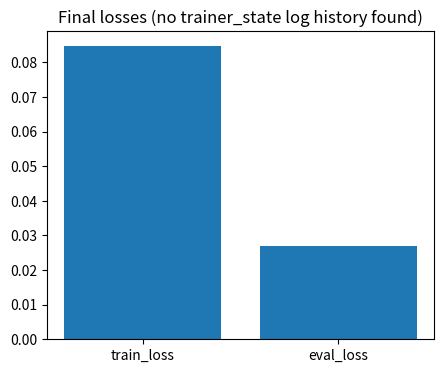

In [10]:
import json

import matplotlib.pyplot as plt

trainer_state_path = Path(result.output_dir) / 'checkpoints' / 'trainer_state.json'
trainer_state = None
if trainer_state_path.exists():
    trainer_state = json.loads(trainer_state_path.read_text(encoding='utf-8'))

if trainer_state and trainer_state.get('log_history'):
    train_points = [(entry['step'], entry['loss']) for entry in trainer_state['log_history'] if 'loss' in entry]
    eval_points = [(entry['step'], entry['eval_loss']) for entry in trainer_state['log_history'] if 'eval_loss' in entry]
    plt.figure(figsize=(8, 4))
    if train_points:
        plt.plot([step for step, _ in train_points], [loss for _, loss in train_points], label='train_loss')
    if eval_points:
        plt.plot([step for step, _ in eval_points], [loss for _, loss in eval_points], label='eval_loss')
    plt.xlabel('step')
    plt.ylabel('loss')
    plt.title('WorldSim v2 baseline training losses')
    plt.legend()
    plt.show()
else:
    final_metrics = {
        'train_loss': summary_artifact.get('train_loss'),
        'eval_loss': summary_artifact.get('eval_loss'),
    }
    plt.figure(figsize=(5, 4))
    plt.bar(final_metrics.keys(), [value if value is not None else 0.0 for value in final_metrics.values()])
    plt.title('Final losses (no trainer_state log history found)')
    plt.show()
    final_metrics


## 11. Analyzer + Registry


In [11]:
import json

from tools.generation_analyzer import generate_report, recommend_next_action
from training.lib.qlora_smoke import (
    BEST_ADAPTER_POINTER_PATH,
    MODEL_REGISTRY_PATH,
    build_baseline_candidate_judgment,
    load_model_registry,
    register_baseline_run,
    select_best_adapter_run,
    update_best_adapter_pointer,
)

analysis_report = generate_report(sample_rows, examples_per_category=3) if sample_rows else None
analysis_report_path = Path(result.output_dir) / 'analysis_report.json'
if analysis_report is not None:
    analysis_report_path.write_text(json.dumps(analysis_report, ensure_ascii=False, indent=2), encoding='utf-8')
analysis_recommendation = recommend_next_action(analysis_report) if analysis_report else None
retry_samples = sum(1 for row in sample_rows if int(row.get('structured_attempt_count', 1) or 1) > 1)
retry_rate = round(retry_samples / len(sample_rows), 4) if sample_rows else None
registry_entry = register_baseline_run(
    MODEL_REGISTRY_PATH,
    config={**CONFIG, 'analysis_report_path': str(analysis_report_path) if analysis_report is not None else None},
    result=result,
    analysis_report=analysis_report,
    metrics={'retry_rate': retry_rate},
    created_at=run_config_artifact.get('generated_at'),
)
registry = load_model_registry(MODEL_REGISTRY_PATH)
best_run = select_best_adapter_run(registry)
best_adapter = update_best_adapter_pointer(BEST_ADAPTER_POINTER_PATH, best_run)
baseline_judgment = build_baseline_candidate_judgment(result, analysis_report)
{
    'analysis_report_path': str(analysis_report_path) if analysis_report is not None else None,
    'analysis_report': analysis_report,
    'analysis_recommendation': analysis_recommendation,
    'retry_rate': retry_rate,
    'registry_path': str(MODEL_REGISTRY_PATH),
    'registry_entry': registry_entry,
    'registered_runs': len(registry.get('runs', [])),
    'best_run': best_run,
    'best_adapter_pointer': str(BEST_ADAPTER_POINTER_PATH),
    'best_adapter': best_adapter,
    'baseline_judgment': baseline_judgment,
}


{'analysis_report_path': 'outputs/baseline/worldsim-v31-mix-v1/run-20260314T134300Z/analysis_report.json',
 'analysis_report': {'total_samples': 65,
  'counts_by_failure_category': {'enum_drift': 1,
   'ok': 59,
   'semantic_drift': 3,
   'semantic_low_quality': 2},
  'malformed_json_count': 0,
  'truncation_count': 0,
  'fenced_json_count': 0,
  'trailing_text_count': 0,
  'prompt_leakage_count': 0,
  'enum_drift_count': 1,
  'extra_key_count': 1,
  'language_drift_count': 0,
  'semantic_low_quality_count': 2,
  'semantic_drift_count': 3,
  'json_parse_failure_rate': 0.0,
  'extra_key_rate': 0.015384615384615385,
  'enum_drift_rate': 0.015384615384615385,
  'retry_rate': 0.07692307692307693,
  'repair_applied_rate': 0.0,
  'constrained_decoding_used_rate': 1.0,
  'structured_success_rate': 0.9692307692307692,
  'affected_tasks_summary': {'B': {'enum_drift': 1},
   'G': {'semantic_drift': 3, 'semantic_low_quality': 2}},
  'extra_key_examples': [{'task': 'K',
    'extra_keys': ['cause_e

## 12. Guardrail Impact Summary


In [12]:
structured_metrics = (metrics_artifact or {}).get('structured_metrics', {})
print('=' * 50)
print('GUARDRAIL IMPACT SUMMARY')
print('=' * 50)
for _k in ['per_sample_success_rate', 'structured_success_rate', 'json_parse_failure_rate', 'repair_applied_rate',
           'extra_key_rate', 'first_attempt_success', 'required_retry', 'max_retries_exhausted']:
    _v = structured_metrics.get(_k, 'N/A')
    print(f"  {_k}: {f'{_v:.4f}' if isinstance(_v, float) else _v}")
print('-' * 50)
_ssr = structured_metrics.get('per_sample_success_rate', structured_metrics.get('structured_success_rate', 0))
if isinstance(_ssr, (int, float)) and _ssr >= 0.95:
    print('>>> PASS: Guardrails achieved 95%+ per-sample structured success <<<')
elif isinstance(_ssr, (int, float)) and _ssr >= 0.85:
    print('>>> PARTIAL: 85-95% — prompt hardening next <<<')
else:
    print('>>> INSUFFICIENT: <85% — constrained decoding needed <<<')
print('=' * 50)
{'guardrail_summary': structured_metrics}


GUARDRAIL IMPACT SUMMARY
  per_sample_success_rate: 0.9231
  structured_success_rate: 0.7500
  json_parse_failure_rate: 0.0000
  repair_applied_rate: 0.0000
  extra_key_rate: 0.0000
  first_attempt_success: 60
  required_retry: 0
  max_retries_exhausted: 5
--------------------------------------------------
>>> PARTIAL: 85-95% — prompt hardening next <<<


{'guardrail_summary': {'total_attempts': 80,
  'total_successes': 60,
  'total_failures': 20,
  'json_parse_failures': 0,
  'schema_validation_failures': 20,
  'repair_applied_count': 0,
  'repairs_by_type': {},
  'keys_removed_count': 0,
  'removed_keys_frequency': {},
  'enums_normalized_count': 0,
  'first_attempt_success': 60,
  'required_retry': 0,
  'max_retries_exhausted': 5,
  'unique_samples': 65,
  'unique_successes': 60,
  'per_task': {'A': {'total': 5, 'success': 5, 'failure': 0},
   'B': {'total': 11, 'success': 3, 'failure': 8},
   'C': {'total': 5, 'success': 5, 'failure': 0},
   'G': {'total': 5, 'success': 5, 'failure': 0},
   'F': {'total': 5, 'success': 5, 'failure': 0},
   'H': {'total': 5, 'success': 5, 'failure': 0},
   'E': {'total': 5, 'success': 5, 'failure': 0},
   'I': {'total': 5, 'success': 5, 'failure': 0},
   'J': {'total': 8, 'success': 4, 'failure': 4},
   'K': {'total': 11, 'success': 3, 'failure': 8},
   'L': {'total': 5, 'success': 5, 'failure': 0},


## 13. Final Operational Judgment


In [13]:
BASELINE_VERDICTS = (
    'PASS_BASELINE_CANDIDATE',
    'PASS_STRUCTURAL_BUT_SEMANTIC_WEAK',
    'FAIL_BLOCKED_RUNTIME',
    'FAIL_TRAINING_INCOMPLETE',
    'FAIL_ARTIFACT_INVALID',
)
final_operational_judgment = {
    'training_completed_successfully': baseline_judgment.get('training_completed_successfully'),
    'used_true_qlora': baseline_judgment.get('used_true_qlora'),
    'adapter_exists': baseline_judgment.get('adapter_exists'),
    'losses_finite': baseline_judgment.get('losses_finite'),
    'structure_stable': baseline_judgment.get('structure_stable'),
    'semantic_quality_is_primary_remaining_issue': baseline_judgment.get('semantic_quality_is_primary_remaining_issue'),
    'is_baseline_candidate': baseline_judgment.get('is_baseline_candidate'),
    'verdict': baseline_judgment.get('verdict'),
    'output_dir': baseline_judgment.get('output_dir'),
    'adapter_dir': baseline_judgment.get('adapter_dir'),
    'train_loss': baseline_judgment.get('train_loss'),
    'eval_loss': baseline_judgment.get('eval_loss'),
    'per_sample_success_rate': structured_metrics.get('per_sample_success_rate') if structured_metrics else None,
    'malformed_json': analysis_report.get('malformed_json_count') if analysis_report else None,
    'fenced_json': analysis_report.get('fenced_json_count') if analysis_report else None,
    'enum_drift_total': sample_summary.get('enum_drift_total') if sample_summary else None,
    'semantic_valid': sample_summary.get('semantic_valid') if sample_summary else None,
    'semantic_low_quality': analysis_report.get('semantic_low_quality_count') if analysis_report else None,
    'semantic_drift': analysis_report.get('semantic_drift_count') if analysis_report else None,
    'language_drift': analysis_report.get('language_drift_count') if analysis_report else None,
    'analyzer_overall_status': analysis_report.get('overall_status') if analysis_report else None,
    'recommended_next_action': baseline_judgment.get('recommended_next_action'),
    'supported_verdicts': BASELINE_VERDICTS,
}
final_operational_judgment


{'training_completed_successfully': True,
 'used_true_qlora': True,
 'adapter_exists': True,
 'losses_finite': True,
 'structure_stable': False,
 'semantic_quality_is_primary_remaining_issue': False,
 'is_baseline_candidate': False,
 'verdict': 'FAIL_ARTIFACT_INVALID',
 'output_dir': 'outputs/baseline/worldsim-v31-mix-v1/run-20260314T134300Z',
 'adapter_dir': 'outputs/baseline/worldsim-v31-mix-v1/run-20260314T134300Z/adapter',
 'train_loss': 0.08478420572700324,
 'eval_loss': 0.026896685361862183,
 'per_sample_success_rate': 0.9230769230769231,
 'malformed_json': 0,
 'fenced_json': 0,
 'enum_drift_total': 1,
 'semantic_valid': 0,
 'semantic_low_quality': 2,
 'semantic_drift': 3,
 'language_drift': 0,
 'analyzer_overall_status': 'structure_failure',
 'recommended_next_action': 'Treat this run as structurally unstable; inspect malformed/truncation/enum failures before considering it as a baseline candidate.',
 'supported_verdicts': ('PASS_BASELINE_CANDIDATE',
  'PASS_STRUCTURAL_BUT_SEMAN

## 14. Guardrail Verification Report (Auto)


In [14]:
from pathlib import Path as _P
import json as _json

from scripts.extract_guardrail_metrics import extract_metrics, print_report

_run_output_dir = result.output_dir if hasattr(result, 'output_dir') else str(result.to_dict().get('output_dir', ''))
_guardrail_data = extract_metrics(_run_output_dir)
print_report(_guardrail_data)

_gr_out = _P(_run_output_dir) / 'guardrail_verification_report.json'
if _P(_run_output_dir).is_dir():
    _gr_out.write_text(_json.dumps(_guardrail_data, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f"JSON report saved to: {_gr_out}")

_guardrail_data


GUARDRAIL VERIFICATION REPORT
Output: /home/hyunlord/github/worldsim-training/outputs/baseline/worldsim-v31-mix-v1/run-20260314T134300Z

--- Structured Metrics (from BatchMetrics) ---
  structured_success_rate: 0.7500
  json_parse_failure_rate: 0.0000
  repair_applied_rate: 0.0000
  extra_key_rate: 0.0000
  total_attempts: 80
  total_successes: 60
  total_failures: 20
  first_attempt_success: 60
  required_retry: 0
  max_retries_exhausted: 5

--- Per-Task Breakdown ---
  Task A: 5/5 (100.00%)
  Task B: 3/11 (27.27%)
  Task C: 5/5 (100.00%)
  Task E: 5/5 (100.00%)
  Task F: 5/5 (100.00%)
  Task G: 5/5 (100.00%)
  Task H: 5/5 (100.00%)
  Task I: 5/5 (100.00%)
  Task J: 4/8 (50.00%)
  Task K: 3/11 (27.27%)
  Task L: 5/5 (100.00%)
  Task M: 5/5 (100.00%)
  Task N: 5/5 (100.00%)

--- Repairs Applied ---
  (none)

--- Top Removed Keys (Schema Leakage) ---
  (none)

--- Analysis Report Summary ---
  overall_status: structure_failure
  structured_success_rate: 0.9692307692307692
  malformed_js

{'output_dir': '/home/hyunlord/github/worldsim-training/outputs/baseline/worldsim-v31-mix-v1/run-20260314T134300Z',
 'structured_metrics': {'total_attempts': 80,
  'total_successes': 60,
  'total_failures': 20,
  'json_parse_failures': 0,
  'schema_validation_failures': 20,
  'repair_applied_count': 0,
  'repairs_by_type': {},
  'keys_removed_count': 0,
  'removed_keys_frequency': {},
  'enums_normalized_count': 0,
  'first_attempt_success': 60,
  'required_retry': 0,
  'max_retries_exhausted': 5,
  'unique_samples': 65,
  'unique_successes': 60,
  'per_task': {'A': {'total': 5, 'success': 5, 'failure': 0},
   'B': {'total': 11, 'success': 3, 'failure': 8},
   'C': {'total': 5, 'success': 5, 'failure': 0},
   'G': {'total': 5, 'success': 5, 'failure': 0},
   'F': {'total': 5, 'success': 5, 'failure': 0},
   'H': {'total': 5, 'success': 5, 'failure': 0},
   'E': {'total': 5, 'success': 5, 'failure': 0},
   'I': {'total': 5, 'success': 5, 'failure': 0},
   'J': {'total': 8, 'success': 4,

## 15. v1 vs v2 Comparison


In [15]:
V1_RESULTS = {
    'structured_success_rate': 1.0,
    'language_drift': 5,
    'train_loss': 0.2665,
    'eval_loss': 0.0464,
    'verdict': 'PASS_STRUCTURAL_BUT_SEMANTIC_WEAK',
    'tasks_covered': 7,
    'train_size': 2201,
}

v2_ssr = structured_metrics.get('per_sample_success_rate', structured_metrics.get('structured_success_rate', 0)) if structured_metrics else 0
v2_ld = analysis_report.get('language_drift_count', '?') if analysis_report else '?'
v2_tl = baseline_judgment.get('train_loss', '?')
v2_el = baseline_judgment.get('eval_loss', '?')
v2_verdict = baseline_judgment.get('verdict', '?')

print('=' * 60)
print('V1 vs V2 COMPARISON')
print('=' * 60)
print(f"{'Metric':<30} {'v1':>12} {'v2':>12} {'Delta':>12}")
print('-' * 66)
print(f"{'Train size':<30} {V1_RESULTS['train_size']:>12} {len(train_rows):>12} {'+' + str(len(train_rows) - V1_RESULTS['train_size']):>12}")
print(f"{'Tasks covered':<30} {V1_RESULTS['tasks_covered']:>12} {len(set(row.get('task') for row in train_rows)):>12}")
if isinstance(v2_ssr, float):
    print(f"{'structured_success_rate':<30} {V1_RESULTS['structured_success_rate']:>12.4f} {v2_ssr:>12.4f}")
else:
    print(f"{'structured_success_rate':<30} {V1_RESULTS['structured_success_rate']:>12.4f} {str(v2_ssr):>12}")
print(f"{'language_drift':<30} {V1_RESULTS['language_drift']:>12} {str(v2_ld):>12}")
if isinstance(v2_tl, float):
    print(f"{'train_loss':<30} {V1_RESULTS['train_loss']:>12.4f} {v2_tl:>12.4f}")
else:
    print(f"{'train_loss':<30} {V1_RESULTS['train_loss']:>12.4f} {str(v2_tl):>12}")
if isinstance(v2_el, float):
    print(f"{'eval_loss':<30} {V1_RESULTS['eval_loss']:>12.4f} {v2_el:>12.4f}")
else:
    print(f"{'eval_loss':<30} {V1_RESULTS['eval_loss']:>12.4f} {str(v2_el):>12}")
print(f"{'verdict':<30} {V1_RESULTS['verdict']:>35}")
print(f"{'':30} {str(v2_verdict):>35}")
print('=' * 60)


V1 vs V2 COMPARISON
Metric                                   v1           v2        Delta
------------------------------------------------------------------
Train size                             2201         3455        +1254
Tasks covered                             7           15
structured_success_rate              1.0000       0.9231
language_drift                            5            0
train_loss                           0.2665       0.0848
eval_loss                            0.0464       0.0269
verdict                          PASS_STRUCTURAL_BUT_SEMANTIC_WEAK
                                             FAIL_ARTIFACT_INVALID
